In [ ]:
!pip install ijson==3.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.1/113.1 kB 4.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import ijson
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from glob import glob

# unless pre preprocessing changes, no need to run above

In [ ]:
imu_sensor_locations = ['Pelvis', 'RightForeArm', 'RightUpperLeg', 'RightLowerLeg', 'LeftUpperLeg', 'LeftLowerLeg']


participant_num = [1, 2, 3, 4, 5, 7, 8, 10, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25]

In [ ]:
import os
import pandas as pd
import logging
import glob

# Set up logging
logging.basicConfig(level=logging.INFO)

def merge_csv_files_in_folder(folder_path, imu_sensor_locations):
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

    filtered_files = [file for file in csv_files if any(sensor_location in file for sensor_location in imu_sensor_locations)]

    if filtered_files:
        try:
            df_list = [pd.read_csv(file, low_memory=False) for file in filtered_files]
            merged_df = pd.concat(df_list, ignore_index=True)
            return merged_df
        except FileNotFoundError as e:
            logging.error(f"Error: File not found: {e}")
        except pd.errors.ParserError as e:
            logging.error(f"Error: Parsing error: {e}")
    else:
        logging.warning(f"No relevant CSV files found in {folder_path}")
        return None

In [ ]:
# Load and process dataframes
folder_path = "/content/drive/MyDrive/Next_Step/Honda: multi_modal_gait_database/processed data"

imu_df = merge_csv_files_in_folder(folder_path, imu_sensor_locations)


In [ ]:
!pip install ijson==3.2.1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import ijson
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import logging
from glob import glob

# unless pre preprocessing changes, no need to run above

In [ ]:
imu_sensor_locations = ['Pelvis', 'RightForeArm', 'RightUpperLeg', 'RightLowerLeg', 'LeftUpperLeg', 'LeftLowerLeg']

insole_sensor_locations = ['Arch', 'Hallux', 'Heel_L', 'Heel_R', 'Met1', 'Met3', 'Met5', 'Toes']

participant_num = [1, 2, 3, 4, 5, 7, 8, 10, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25]

In [ ]:
import pandas as pd
import glob


# Specify the directory where your ORIGINAL CSV files are stored
original_data_dir = "/content/drive/MyDrive/Next_Step/Honda: multi_modal_gait_database/processed_data"  # Replace with the correct path

# Create an empty list to store the DataFrames
imu_dfs = []

# Use glob to find files that match the pattern with imu sensor locations
for location in imu_sensor_locations:
    file_pattern = f"{original_data_dir}/*_{location}_*.csv"
    files = glob.glob(file_pattern)

    for file in files:
        try:
            # Load the CSV file
            df = pd.read_csv(file)

            # Debugging: Print file name and DataFrame shape
            print(f"Loaded: {file}, Shape: {df.shape}")

            # Append the DataFrame to the list
            imu_dfs.append(df)
        except Exception as e:
            # Handle any errors during file reading
            print(f"Error loading {file}: {e}")

# Combine all the DataFrames into one (optional)
if imu_dfs:
    combined_df = pd.concat(imu_dfs, ignore_index=True)
    print(f"Combined DataFrame Shape: {combined_df.shape}")
else:
    print("No matching files were loaded.")


Loaded: /content/drive/MyDrive/Next_Step/Honda: multi_modal_gait_database/processed_data/participant_13_Pelvis_C.csv, Shape: (23653, 36)
Loaded: /content/drive/MyDrive/Next_Step/Honda: multi_modal_gait_database/processed_data/participant_12_Pelvis_C.csv, Shape: (25578, 36)
Loaded: /content/drive/MyDrive/Next_Step/Honda: multi_modal_gait_database/processed_data/participant_14_Pelvis_C.csv, Shape: (22906, 36)
Loaded: /content/drive/MyDrive/Next_Step/Honda: multi_modal_gait_database/processed_data/participant_24_Pelvis_C.csv, Shape: (22484, 36)
Loaded: /content/drive/MyDrive/Next_Step/Honda: multi_modal_gait_database/processed_data/participant_25_Pelvis_C.csv, Shape: (23972, 36)
Loaded: /content/drive/MyDrive/Next_Step/Honda: multi_modal_gait_database/processed_data/participant_15_Pelvis_C.csv, Shape: (25112, 36)
Loaded: /content/drive/MyDrive/Next_Step/Honda: multi_modal_gait_database/processed_data/participant_1_Pelvis_C.csv, Shape: (24286, 36)
Loaded: /content/drive/MyDrive/Next_Step/H

In [13]:
imu_df = combined_df.copy()

In [14]:
imu_df.sort_values(by=['participant_id', 'time', 'sensor_location'])

,time,participant_id,task,walk_mode,insoles_RightFoot_is_step,insoles_RightFoot_is_lifted,insoles_LeftFoot_is_step,insoles_LeftFoot_is_lifted,sensor_location,orientation_qi,...,angularAcceleration_z,sensorFreeAcceleration_x,sensorFreeAcceleration_y,sensorFreeAcceleration_z,sensorMagneticField_x,sensorMagneticField_y,sensorMagneticField_z,sensorOrientation_qi,sensorOrientation_qj,sensorOrientation_qk
10274725,0,1,C,walk,True,False,True,False,LeftLowerLeg,0.178531,...,28.656103,-0.097483,-14.263696,0.862982,0.875488,0.258301,0.487061,0.616794,0.614567,-0.299376
10611605,0,1,B,walk,True,False,True,False,LeftLowerLeg,0.234964,...,-5.694370,4.963941,-11.357665,0.314277,0.577637,-0.183105,0.831055,0.359051,0.783833,0.025429
11687675,0,1,A,walk,True,False,True,False,LeftLowerLeg,0.005944,...,-63.304398,-7.421082,0.025310,-2.897807,0.984375,0.174805,0.521240,0.047658,0.668715,-0.083689
8248521,0,1,C,walk,True,False,True,False,LeftUpperLeg,0.136800,...,-18.513706,0.452208,-8.084704,-1.200215,0.719238,-0.126221,0.561768,-0.066359,0.766161,0.158964
8585401,0,1,B,walk,True,False,True,False,LeftUpperLeg,0.139012,...,-17.184770,2.507195,-7.543090,-0.839877,0.657227,-0.543213,0.308105,-0.173234,0.716784,0.324564
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9620273,771750,25,A,walk,False,False,False,False,LeftUpperLeg,0.231815,...,129.304948,8.181081,2.842383,-2.968389,0.419922,0.520508,0.878418,0.132940,0.843419,-0.305933
1515457,771750,25,A,walk,False,False,False,False,Pelvis,-0.052419,...,25.353219,-0.008628,-0.057254,-0.656289,0.989746,-0.455566,0.161865,-0.039382,0.590540,0.176147
3541661,771750,25,A,walk,False,False,False,False,RightForeArm,0.035394,...,3.262555,5.625317,1.328285,-5.821044,0.095947,0.173584,-1.086670,0.251861,-0.014785,-0.950229
7594069,771750,25,A,walk,False,False,False,False,RightLowerLeg,-0.331393,...,-15.608165,-11.934079,-4.862423,0.459956,0.958008,0.335693,0.274902,0.903719,0.106299,-0.414093


In [15]:
imu_df['walk_mode'].value_counts()

,count
walk_mode,
walk,6736782
slope_down,2164050
slope_up,1612350
stairs_up,948804
stairs_down,539856
pavement_up,78450
pavement_down,76932


In [16]:
# show all the rows in the df
pd.set_option('display.max_rows', None)

In [17]:
# Function to pair heel strikes with the next toe-off event
def pair_heel_strikes_toe_offs(heel_strikes, toe_offs):
    pairs = []
    toe_idx = 0
    # Loop over each heel strike
    for heel in heel_strikes:
        # Find the next toe-off that occurs after the heel strike
        while toe_idx < len(toe_offs) and toe_offs[toe_idx] < heel:
            toe_idx += 1
        if toe_idx < len(toe_offs):
            # Pair found
            pairs.append((heel, toe_offs[toe_idx]))
            toe_idx += 1  # Move to the next toe-off for the next pair
    return pairs


In [19]:
# Initialize step count columns
imu_df['right_step_count'] = np.nan
imu_df['left_step_count'] = np.nan

for p, participant_df in imu_df.groupby('participant_id'):
    for t in participant_df['task'].unique():
        # print(f"Processing participant {p}, task {t}...")
        # print("-------------------------")

        # Filter once per participant-task
        current_df = participant_df[participant_df['task'] == t].copy()

        # Define heel strikes and toe-offs for the right foot
        right_foot_heel_strikes = current_df[
            (current_df['insoles_RightFoot_is_step'] == True) &
            (current_df['insoles_RightFoot_is_lifted'] == False)]
        right_foot_toe_off = current_df[
            (current_df['insoles_RightFoot_is_step'] == False) &
            (current_df['insoles_RightFoot_is_lifted'] == True)]

        # Define heel strikes and toe-offs for the left foot
        left_foot_heel_strikes = current_df[
            (current_df['insoles_LeftFoot_is_step'] == True) &
            (current_df['insoles_LeftFoot_is_lifted'] == False)]
        left_foot_toe_off = current_df[
            (current_df['insoles_LeftFoot_is_step'] == False) &
            (current_df['insoles_LeftFoot_is_lifted'] == True)]

        # Convert heel strikes and toe-offs to lists
        heel_strike_R = list(right_foot_heel_strikes['time'])
        toe_off_R = list(right_foot_toe_off['time'])

        heel_strike_L = list(left_foot_heel_strikes['time'])
        toe_off_L = list(left_foot_toe_off['time'])


        right_foot_steps = pair_heel_strikes_toe_offs(heel_strike_R, toe_off_R)
        left_foot_steps = pair_heel_strikes_toe_offs(heel_strike_L, toe_off_L)

        # Vectorized step count assignment
        for i, (start, end) in enumerate(right_foot_steps):
            mask = (current_df['time'] >= start) & (current_df['time'] <= end)
            current_df.loc[mask, 'right_step_count'] = i + 1

        for i, (start, end) in enumerate(left_foot_steps):
            mask = (current_df['time'] >= start) & (current_df['time'] <= end)
            current_df.loc[mask, 'left_step_count'] = i + 1

        # Update the original DataFrame (if necessary)
        imu_df.loc[current_df.index, ['right_step_count', 'left_step_count']] = current_df[['right_step_count', 'left_step_count']]

        print(f"Processed participant {p}, task {t}")



Processed participant 1, task C
Processed participant 1, task B
Processed participant 1, task A
Processed participant 2, task C
Processed participant 2, task B
Processed participant 2, task A
Processed participant 3, task C
Processed participant 3, task B
Processed participant 3, task A
Processed participant 4, task B
Processed participant 4, task A
Processed participant 4, task C
Processed participant 5, task C
Processed participant 5, task B
Processed participant 5, task A
Processed participant 7, task C
Processed participant 7, task B
Processed participant 7, task A
Processed participant 8, task C
Processed participant 8, task B
Processed participant 8, task A
Processed participant 10, task C
Processed participant 10, task B
Processed participant 10, task A
Processed participant 12, task C
Processed participant 12, task B
Processed participant 12, task A
Processed participant 13, task C
Processed participant 13, task B
Processed participant 13, task A
Processed participant 14, task 

In [20]:
imu_df['right_gait_cycle'] = imu_df['right_step_count'].fillna(method='ffill')
imu_df['left_gait_cycle'] = imu_df['left_step_count'].fillna(method='ffill')


<ipython-input-20-5f4e790f6519>:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  imu_df['right_gait_cycle'] = imu_df['right_step_count'].fillna(method='ffill')
<ipython-input-20-5f4e790f6519>:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  imu_df['left_gait_cycle'] = imu_df['left_step_count'].fillna(method='ffill')


In [21]:
imu_df['participant_id'].unique()

array([13, 12, 14, 24, 25, 15,  1,  7, 23,  8, 22,  5, 18,  2, 16,  3, 19,
       17, 10,  4])

In [28]:
# fill left_gait_cycle nans with certain value
imu_df['left_gait_cycle'] = imu_df['left_gait_cycle'].fillna(method='bfill')


<ipython-input-28-62d24c8f8a6c>:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  imu_df['left_gait_cycle'] = imu_df['left_gait_cycle'].fillna(method='bfill')


In [29]:
imu_df['gait_cycle_id'] = imu_df['participant_id'].astype(str) + '_' + \
                         imu_df['left_gait_cycle'].astype(str) + '_' + \
                         imu_df['task'].astype(str)

In [59]:
imu_df.columns

Index(['time', 'participant_id', 'task', 'walk_mode',
       'insoles_RightFoot_is_step', 'insoles_RightFoot_is_lifted',
       'insoles_LeftFoot_is_step', 'insoles_LeftFoot_is_lifted',
       'sensor_location', 'orientation_qi', 'orientation_qj', 'orientation_qk',
       'position_x', 'position_y', 'position_z', 'velocity_x', 'velocity_y',
       'velocity_z', 'acceleration_x', 'acceleration_y', 'acceleration_z',
       'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z',
       'angularAcceleration_x', 'angularAcceleration_y',
       'angularAcceleration_z', 'sensorFreeAcceleration_x',
       'sensorFreeAcceleration_y', 'sensorFreeAcceleration_z',
       'sensorMagneticField_x', 'sensorMagneticField_y',
       'sensorMagneticField_z', 'sensorOrientation_qi', 'sensorOrientation_qj',
       'sensorOrientation_qk', 'right_step_count', 'left_step_count',
       'right_gait_cycle', 'left_gait_cycle', 'gait_cycle_id'],
      dtype='object')

In [60]:
# imu_df.head(100)

In [31]:
# Create a copy of the DataFrame to modify
final_combined_df = imu_df.copy()

In [32]:
# Rename 'pavement_up' to 'stairs_up' and 'pavement_down' to 'stairs_down'
final_combined_df['walk_mode'] = final_combined_df['walk_mode'].replace({'pavement_up': 'stairs_up', 'pavement_down': 'stairs_down'})

In [33]:
final_combined_df['walk_mode'].value_counts()

,count
walk_mode,
walk,6736782
slope_down,2164050
slope_up,1612350
stairs_up,1027254
stairs_down,616788


In [34]:
final_combined_df.sort_values(by=['participant_id', 'gait_cycle_id', 'time', 'sensor_location'], inplace=True)

In [35]:
final_combined_df['participant_id'].unique()

array([ 1,  2,  3,  4,  5,  7,  8, 10, 12, 13, 14, 15, 16, 17, 18, 19, 22,
       23, 24, 25])

In [36]:
import random

number_list = list(final_combined_df['participant_id'].unique())
random.seed(67)
# Choose 3 numbers without replacement
test_three_numbers = random.sample(number_list, 3)
print(test_three_numbers)
train_list = [x for x in number_list if x not in test_three_numbers]

val_three_numbers = random.sample(train_list, 3)
print(val_three_numbers)

train_list = [x for x in train_list if x not in val_three_numbers]
print(train_list)

[3, 4, 17]
[23, 22, 8]
[1, 2, 5, 7, 10, 12, 13, 14, 15, 16, 18, 19, 24, 25]


In [42]:
# Function to calculate cycle lengths
def calculate_cycle_lengths(df, sensor_location='LeftLowerLeg'):
    # Filter the data by sensor location
    df_sensor = df[df['sensor_location'] == sensor_location]

    # Calculate cycle lengths (number of entries per gait cycle)
    cycle_lengths = df_sensor.groupby('gait_cycle_id').size()

    return cycle_lengths

def calculate_bounds(cycle_lengths, margin=10, min_length=41, max_length=85):
    # Calculate Q1 (25th percentile), Q3 (75th percentile), and IQR
    q1 = np.percentile(cycle_lengths, 25)
    q3 = np.percentile(cycle_lengths, 75)
    iqr = q3 - q1

    # Define the bounds, ensuring they're within the defined min and max lengths
    lower_bound = max(q1 - 1.5 * iqr, min_length) - margin  # Ensure lower bound is not below min_length
    upper_bound = min(q3 + 1.5 * iqr, max_length) + margin  # Ensure upper bound is not above max_length

    return lower_bound, upper_bound

# Function to filter out cycle lengths outside the bounds
def filter_cycle_lengths(cycle_lengths, lower_bound, upper_bound):
    # Filter out cycle lengths that are outside the calculated bounds
    return cycle_lengths[(cycle_lengths >= lower_bound) & (cycle_lengths <= upper_bound)]


In [43]:
def get_valid_gait_cycle_ids(df, lower_bound, upper_bound, sensor_location='LeftLowerLeg'):
    # Calculate cycle lengths
    cycle_lengths = calculate_cycle_lengths(df, sensor_location=sensor_location)

    # Filter cycle lengths
    filtered_cycle_lengths = filter_cycle_lengths(cycle_lengths, lower_bound, upper_bound)

    # Return valid gait cycle IDs
    return filtered_cycle_lengths.index

# Step 2: Filter the original DataFrame based on valid gait cycle IDs
def filter_original_dataframe(df, valid_gait_cycle_ids):
    # Keep only rows with valid gait_cycle_id values
    return df[df['gait_cycle_id'].isin(valid_gait_cycle_ids)]


In [44]:
# Apply the cycle length calculation and filtering to the full dataset
cycle_lengths = calculate_cycle_lengths(final_combined_df)

# Calculate bounds (with margin for flexibility)
lower_bound, upper_bound = calculate_bounds(cycle_lengths)

# Filter the cycle lengths based on the calculated bounds
filtered_cycle_lengths = filter_cycle_lengths(cycle_lengths, lower_bound, upper_bound)

# Get valid gait cycle IDs
valid_gait_cycle_ids = get_valid_gait_cycle_ids(final_combined_df, lower_bound, upper_bound)

# Filter the original DataFrame
filtered_final_combined_df = filter_original_dataframe(final_combined_df, valid_gait_cycle_ids)


# Now group by 'walk_mode' to examine cycle lengths by surface type
filtered_cycle_lengths_by_surface = {}
for surface in final_combined_df['walk_mode'].unique():
    # Filter data by surface and calculate cycle lengths
    surface_df = final_combined_df[final_combined_df['walk_mode'] == surface]
    surface_cycle_lengths = calculate_cycle_lengths(surface_df)

    # Apply the filter to remove cycle lengths outside the bounds
    filtered_surface_cycle_lengths = filter_cycle_lengths(surface_cycle_lengths, lower_bound, upper_bound)

    # Store the filtered cycle lengths for each surface type
    filtered_cycle_lengths_by_surface[surface] = filtered_surface_cycle_lengths


# Now group by 'participant' to examine cycle lengths by surface type
filtered_cycle_lengths_by_participant = {}
for participant in final_combined_df['participant_id'].unique():
    # Filter data by surface and calculate cycle lengths
    participant_df = final_combined_df[final_combined_df['participant_id'] == participant]
    participant_cycle_lengths = calculate_cycle_lengths(participant_df)

    # Apply the filter to remove cycle lengths outside the bounds
    filtered_participant_cycle_lengths = filter_cycle_lengths(participant_cycle_lengths, lower_bound, upper_bound)

    # Store the filtered cycle lengths for each surface type
    filtered_cycle_lengths_by_participant[participant] = filtered_participant_cycle_lengths

# Optional: Print out the results for each surface
for surface, lengths in filtered_cycle_lengths_by_surface.items():
    print(f"Surface: {surface}, Filtered Cycle Lengths: {len(lengths)}")


Surface: walk, Filtered Cycle Lengths: 16958
Surface: stairs_down, Filtered Cycle Lengths: 1406
Surface: slope_down, Filtered Cycle Lengths: 5621
Surface: stairs_up, Filtered Cycle Lengths: 2432
Surface: slope_up, Filtered Cycle Lengths: 4103


In [45]:
def biomech_metrics(gc_len):
    gait_cycle_duration = gc_len/ 60
    gait_cycles_per_min = 60/gait_cycle_duration
    steps_per_min = 2 * gait_cycles_per_min
    print(f"Gait cycle duration: {gait_cycle_duration} seconds")
    print(f"Gait cycles per minute: {gait_cycles_per_min}")
    print(f"Steps per minute: {steps_per_min}")

    return gait_cycle_duration, gait_cycles_per_min, steps_per_min

In [46]:
lower_gc_duration, lower_gc_per_min, lower_step_per_min = biomech_metrics(lower_bound)

Gait cycle duration: 0.6833333333333333 seconds
Gait cycles per minute: 87.80487804878048
Steps per minute: 175.60975609756096


In [47]:
upper_gc_duration, upper_gc_per_min, upper_step_per_min = biomech_metrics(upper_bound)

Gait cycle duration: 1.4166666666666667 seconds
Gait cycles per minute: 42.35294117647059
Steps per minute: 84.70588235294117


Surface: walk, Min Length: 41, Max Length: 85, Count: 16958
Surface: stairs_down, Min Length: 41, Max Length: 83, Count: 1406
Surface: slope_down, Min Length: 41, Max Length: 78, Count: 5621
Surface: stairs_up, Min Length: 41, Max Length: 85, Count: 2432
Surface: slope_up, Min Length: 41, Max Length: 83, Count: 4103


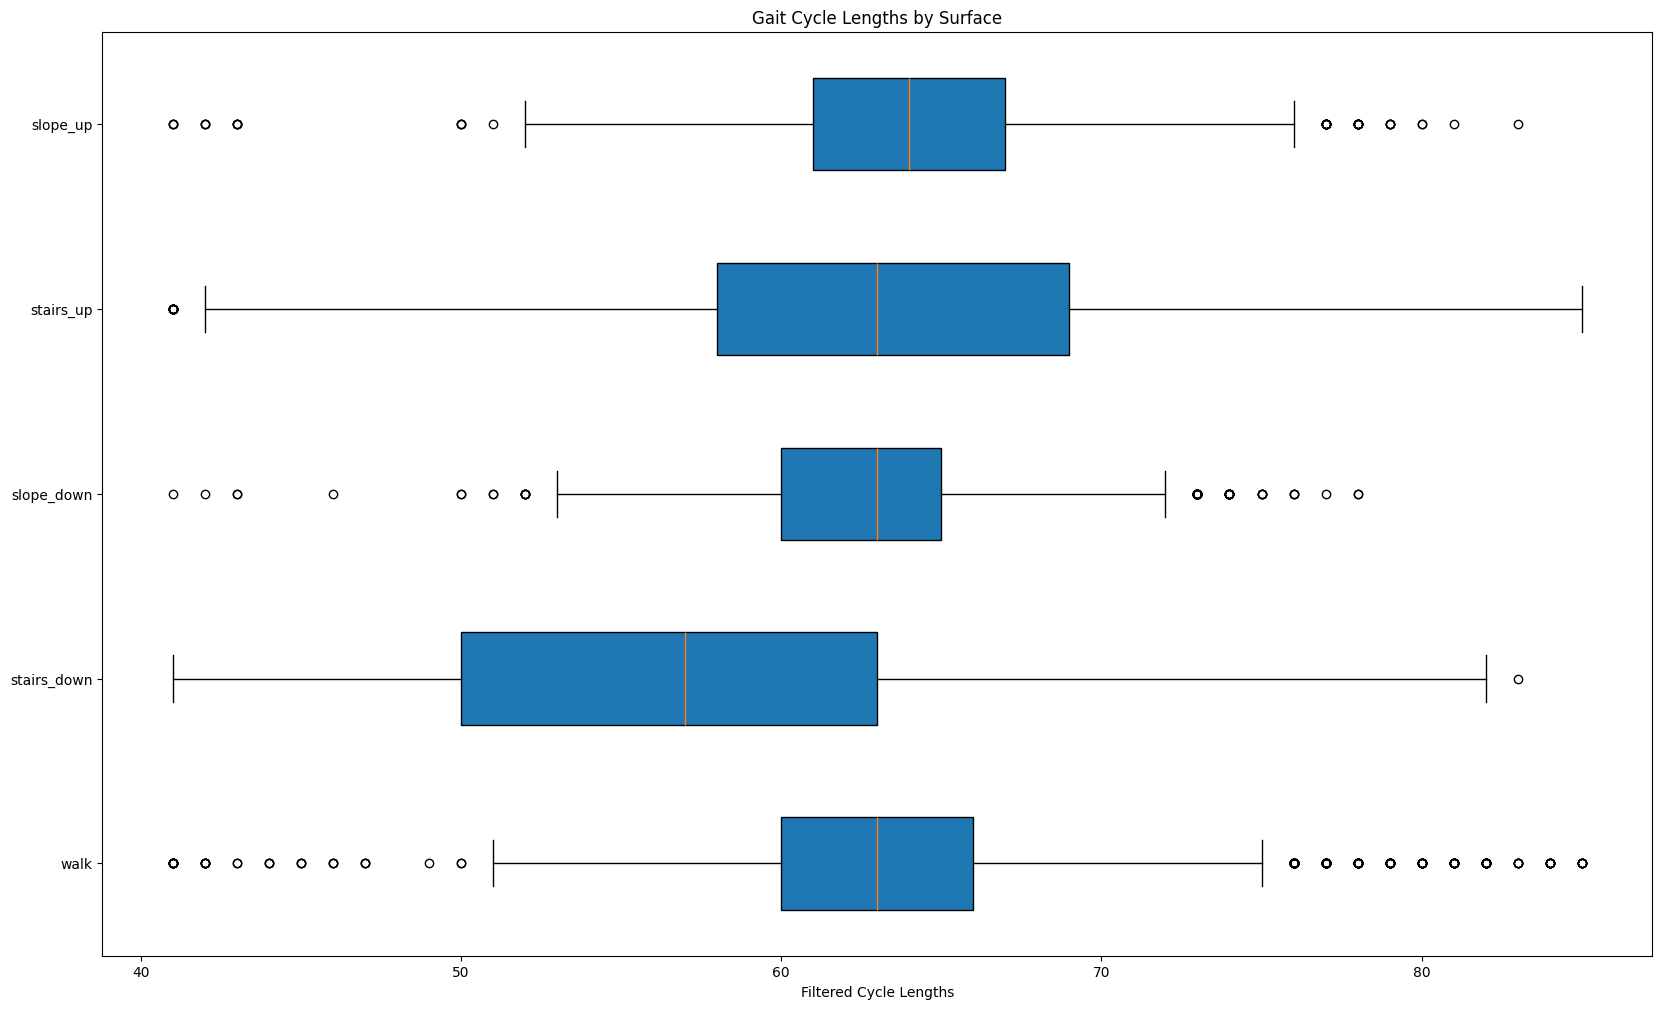

In [48]:
# Print summary of filtered cycle lengths for each surface type
for surface, lengths in filtered_cycle_lengths_by_surface.items():
    print(f"Surface: {surface}, Min Length: {min(lengths)}, Max Length: {max(lengths)}, Count: {len(lengths)}")

# Visualize the filtered cycle lengths using a box plot
labels = filtered_cycle_lengths_by_surface.keys()
data = filtered_cycle_lengths_by_surface.values()

plt.figure(figsize=(20, 12))
plt.boxplot(data, vert=False, patch_artist=True, labels=labels)

# Add labels and title to the plot
plt.xlabel('Filtered Cycle Lengths')
plt.title('Gait Cycle Lengths by Surface')
plt.show()

Participant: 1, Min Length: 41, Max Length: 80, Count: 1717
Participant: 2, Min Length: 41, Max Length: 79, Count: 1564
Participant: 3, Min Length: 41, Max Length: 85, Count: 1469
Participant: 4, Min Length: 41, Max Length: 82, Count: 1579
Participant: 5, Min Length: 42, Max Length: 85, Count: 1448
Participant: 7, Min Length: 41, Max Length: 83, Count: 1632
Participant: 8, Min Length: 41, Max Length: 85, Count: 1704
Participant: 10, Min Length: 41, Max Length: 84, Count: 1596
Participant: 12, Min Length: 42, Max Length: 84, Count: 1772
Participant: 13, Min Length: 41, Max Length: 80, Count: 1546
Participant: 14, Min Length: 41, Max Length: 85, Count: 1463
Participant: 15, Min Length: 42, Max Length: 80, Count: 1607
Participant: 16, Min Length: 44, Max Length: 85, Count: 1619
Participant: 17, Min Length: 41, Max Length: 85, Count: 1350
Participant: 18, Min Length: 41, Max Length: 82, Count: 1668
Participant: 19, Min Length: 41, Max Length: 76, Count: 1422
Participant: 22, Min Length: 41

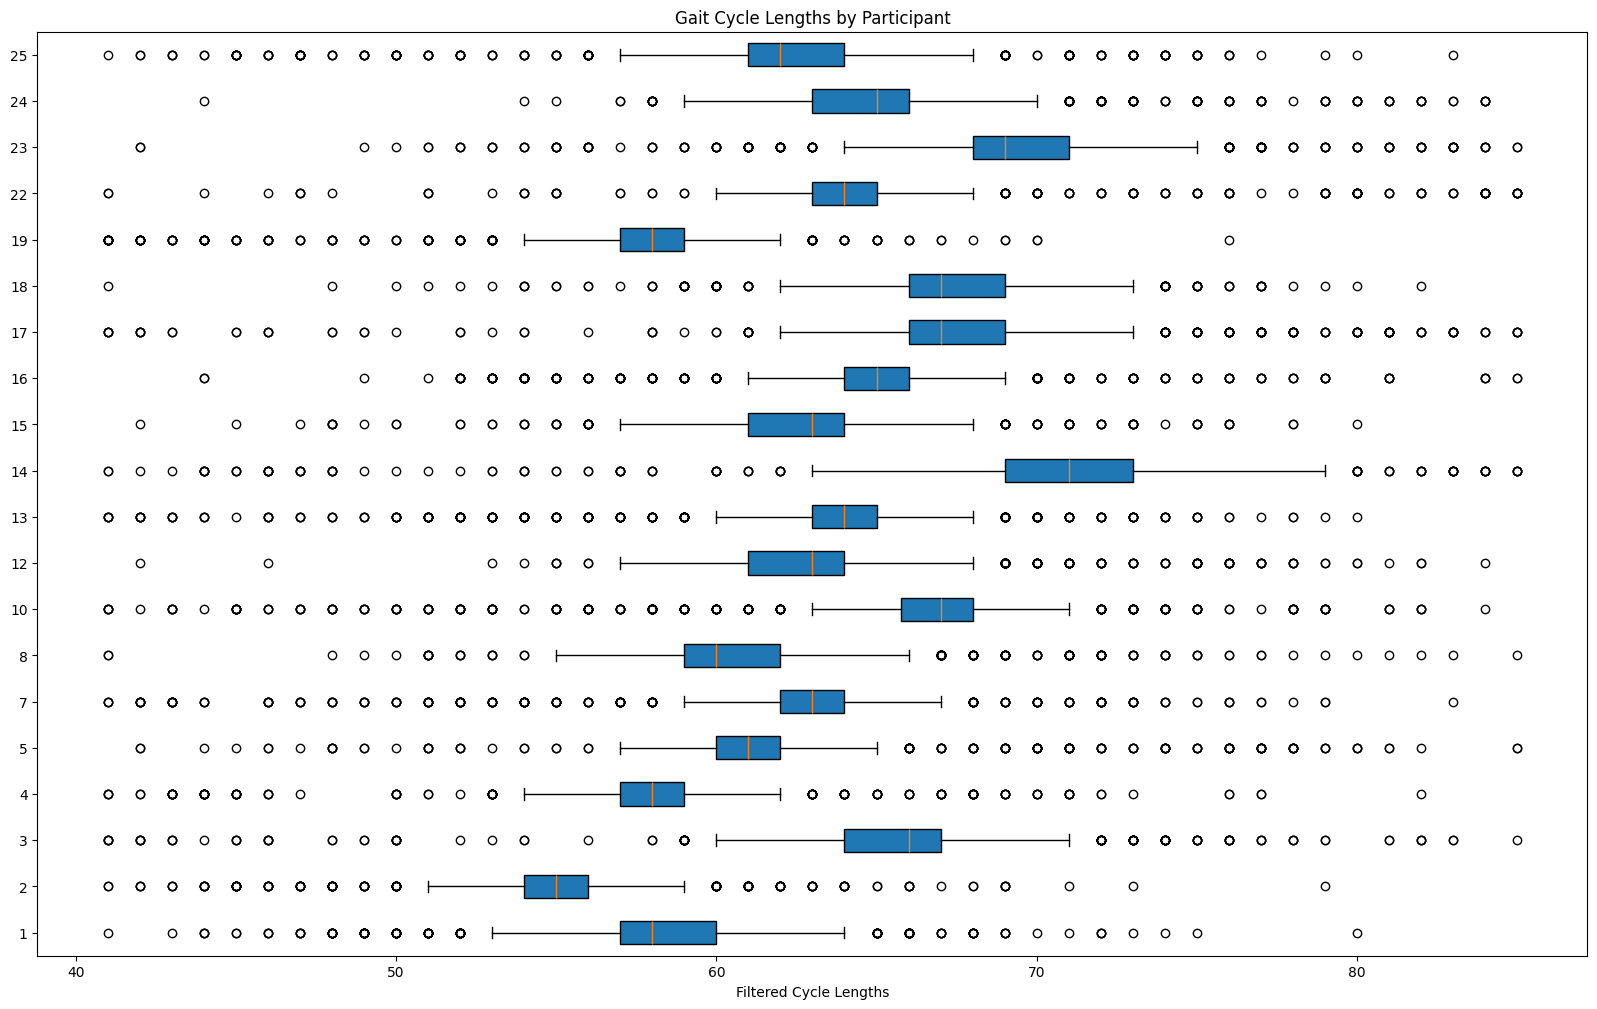

In [49]:
# Print summary of filtered cycle lengths for each surface type
for participant, lengths in filtered_cycle_lengths_by_participant.items():
    print(f"Participant: {participant}, Min Length: {min(lengths)}, Max Length: {max(lengths)}, Count: {len(lengths)}")

# Visualize the filtered cycle lengths using a box plot
labels = filtered_cycle_lengths_by_participant.keys()
data = filtered_cycle_lengths_by_participant.values()

plt.figure(figsize=(20, 12))
plt.boxplot(data, vert=False, patch_artist=True, labels=labels)

# Add labels and title to the plot
plt.xlabel('Filtered Cycle Lengths')
plt.title('Gait Cycle Lengths by Participant')
plt.show()

In [50]:
filtered_final_combined_df['cycle_length'] = calculate_cycle_lengths(filtered_final_combined_df).reindex(
    filtered_final_combined_df['gait_cycle_id']
).values

<ipython-input-50-a251e6ce2436>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_final_combined_df['cycle_length'] = calculate_cycle_lengths(filtered_final_combined_df).reindex(


In [53]:
all_gait_cycles = filtered_final_combined_df.copy()

In [54]:
all_gait_cycles.sort_values(by=['participant_id', "left_gait_cycle", 'task'], inplace=True)

In [55]:
all_gait_cycles.columns

Index(['time', 'participant_id', 'task', 'walk_mode',
       'insoles_RightFoot_is_step', 'insoles_RightFoot_is_lifted',
       'insoles_LeftFoot_is_step', 'insoles_LeftFoot_is_lifted',
       'sensor_location', 'orientation_qi', 'orientation_qj', 'orientation_qk',
       'position_x', 'position_y', 'position_z', 'velocity_x', 'velocity_y',
       'velocity_z', 'acceleration_x', 'acceleration_y', 'acceleration_z',
       'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z',
       'angularAcceleration_x', 'angularAcceleration_y',
       'angularAcceleration_z', 'sensorFreeAcceleration_x',
       'sensorFreeAcceleration_y', 'sensorFreeAcceleration_z',
       'sensorMagneticField_x', 'sensorMagneticField_y',
       'sensorMagneticField_z', 'sensorOrientation_qi', 'sensorOrientation_qj',
       'sensorOrientation_qk', 'right_step_count', 'left_step_count',
       'right_gait_cycle', 'left_gait_cycle', 'gait_cycle_id', 'cycle_length'],
      dtype='object')

In [56]:
all_gait_cycles['left_gait_cycle'].unique()

array([1.000e+00, 2.000e+00, 3.000e+00, ..., 4.329e+03, 4.330e+03,
       4.331e+03])

In [61]:
def interpolate_to_fixed_length(group, target_length=80):
    interpolated_group = []

    # Iterate over each sensor location within the group
    for sensor_location, data in group.groupby('sensor_location'):
        # Select only numeric columns for interpolation
        numeric_data = data[['time', 'acceleration_x', 'acceleration_y', 'acceleration_z', 'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z']]
        numeric_data = numeric_data.reset_index(drop=True)
        original_length = len(numeric_data)

        if original_length < 2:
            # Skip groups with insufficient data for interpolation
            print(f"Skipping sensor_location '{sensor_location}' with insufficient data.")
            continue

        # Create new evenly spaced indices
        new_indices = np.linspace(0, original_length - 1, target_length)

        # Interpolate the numeric data to the new indices
        interpolated_data = pd.DataFrame(
            {col: np.interp(new_indices, np.arange(original_length), numeric_data[col])
             for col in numeric_data.columns},
            index=new_indices
        )

        # Add back the sensor location information
        interpolated_data['sensor_location'] = sensor_location
        interpolated_data['gait_cycle_id'] = group['gait_cycle_id'].iloc[0]
        interpolated_data['walk_mode'] = group['walk_mode'].iloc[0]

        # Append to the results list
        interpolated_group.append(interpolated_data)

    # Combine all sensor locations back into a single DataFrame
    return pd.concat(interpolated_group, axis=0) if interpolated_group else pd.DataFrame()


In [62]:
# Apply the interpolation function
df_interpolated = (
    all_gait_cycles.groupby('gait_cycle_id')
    .apply(interpolate_to_fixed_length)
    .reset_index(drop=True)
)


<ipython-input-62-10383d9c33e5>:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(interpolate_to_fixed_length)


In [ ]:
# only_luo.to_csv('/content/drive/MyDrive/Next_Step/Honda: multi_modal_gait_database/merged/only_luo_imu_sensor_df.csv', index=False)

In [63]:
imu_df.to_csv('/content/drive/MyDrive/Next_Step/Honda: multi_modal_gait_database/merged/luo_imu_sensor_df.csv', index=False)